# Machine Learning Analysis of Audio-Stimulated fMRI  
## Dataset: ds000158 (Voice vs Non-Voice)

### Research Question
Does human auditory cortex represent vocal sounds using spectro-temporal acoustic features, and which computational model best explains voxelwise fMRI responses?

### Framework
Encoding model + Decoding + RSA + Model comparison + Uncertainty

### Data source 
https://openneuro.org/datasets/ds000158/versions/1.0.0/download

### References

Naselaris et al., 2011 — Encoding models  
Kriegeskorte et al., 2008 — RSA  
Kell et al., 2018 — Deep auditory models  
Theunissen et al., 2001 — Spectrotemporal receptive fields  
Nili et al., 2014 — Noise ceiling estimation

## 0. & 1. Environment Setup & Import libraries

In [24]:
# If running first time, uncomment

# !conda create -n audio_fmri python=3.10 -y
# !conda activate audio_fmri

# !pip install numpy scipy pandas matplotlib seaborn scikit-learn
# !pip install nibabel nilearn librosa soundfile
# !pip install pybids tqdm

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nibabel as nib
from nilearn import image, masking, plotting, signal
from nilearn.maskers import NiftiMasker

from sklearn.linear_model import RidgeCV
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, accuracy_score

import librosa
import soundfile as sf

from tqdm import tqdm

np.random.seed(0)

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from nilearn.decoding import Decoder

## 2. Set paths

In [28]:
DATA_DIR = "C:/Users/hi/Documents/YLL_evol/Speech-fMRI-Machine-Learning"
SUBJECT = "sub-001" 

FUNC_DIR = os.path.join(DATA_DIR, SUBJECT, "func")
STIM_DIR = os.path.join(DATA_DIR, "sourcedata", "stimuli")

# FUNC_DIR = DATA_DIR + "/" + SUBJECT + "/" + "func"
# STIM_DIR = DATA_DIR + "/" + "sourcedata" + "/" + "stimuli"

print(FUNC_DIR)
print(STIM_DIR)

C:/Users/hi/Documents/YLL_evol/Speech-fMRI-Machine-Learning\sub-001\func
C:/Users/hi/Documents/YLL_evol/Speech-fMRI-Machine-Learning\sourcedata\stimuli


## 3. Download dataset (OpenNeuro)
Manual download:

https://openneuro.org/datasets/ds000158

In [29]:
# optional automatic download

# !pip install openneuro-py

# from openneuro import download

# download(
#     dataset="ds000158",
#     target_dir=DATA_DIR,
#     include=[SUBJECT]
# )

## 4. Inspect dataset structure

In [30]:
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:5]:
        print(f"{indent}  {f}")

Speech-fMRI-Machine-Learning/
  CHANGES
  dataset_description.json
  encoding_results.csv
  README
  rsa_results.csv
  .ipynb_checkpoints/
    Speech_fMRI-checkpoint.ipynb
    Speech_fMRI-Copy1-checkpoint.ipynb
  derivatives/
    workflow/
      2nd_level_batch.mat
      connectivity_analysis.m
      First_level_block_analysis.m
      First_level_event_analysis.m
      LI.mat
      adaptative_threshold/
        adaptative_threshold.m
        adaptive_thresholding.m
        Distribution.m
        ExpectationMaximization.m
        fnhum-06-00245-g001.jpg
      LI/
        history.txt
        LI.m
        LI_boot.m
        LI_boot_hf.m
        LI_cfg_tbx.m
        data/
          aalmasks.zip
          demo.fig
          demo.jpg
          LI-central-mask.hdr
          LI-central-mask.img
      logs/
        sub-001-0012-00001-000192-01_brain_FAST_restore_log.txt
        sub-002-0014-00001-000192-01_brain_FAST_restore_log.txt
        sub-003-0012-00001-000192-01_brain_FAST_restore_log.txt

## 5. Load fMRI data

In [31]:
bold_file = [f for f in os.listdir(FUNC_DIR) if "bold" in f][0]

bold_path = os.path.join(FUNC_DIR, bold_file)

img = nib.load(bold_path)

print("Shape:", img.shape)
print("TR:", img.header.get_zooms())

Shape: (70, 70, 32, 310)
TR: (np.float32(3.0), np.float32(3.0), np.float32(3.3), np.float32(2.0))


### fMRI Data Structure

Shape:

X × Y × Z × Time

Typical:

64 × 64 × 36 × 200

Each voxel = BOLD signal time series  (A voxel is a 3D pixel in brain imaging)

We will model:

Audio features → voxel responses

## 6. Plot mean brain

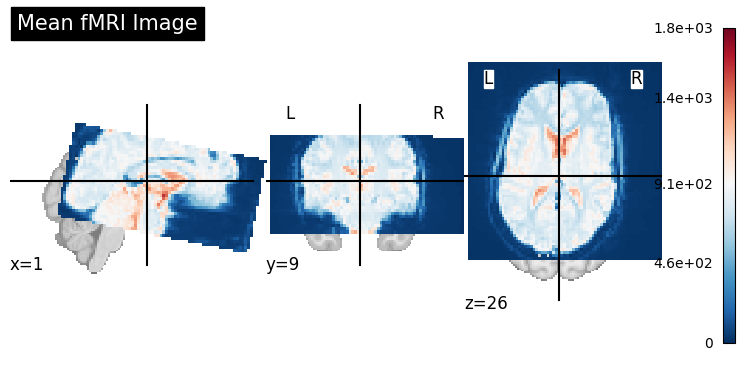

In [32]:
mean_img = image.mean_img(img)

plotting.plot_stat_map(mean_img, title="Mean fMRI Image")
plt.show()

## 7. Extract time series

We standardize BOLD signals:

mean = 0  
variance = 1  

This improves regression stability.

In [33]:
masker = NiftiMasker(
    standardize=True,
    smoothing_fwhm=4,
    detrend=True
)

fmri = masker.fit_transform(img)

print("fmri shape:", fmri.shape)

C:\Users\hi\AppData\Local\Temp\ipykernel_10284\1537599178.py:7: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  fmri = masker.fit_transform(img)


fmri shape: (310, 156800)


In [73]:
masker = NiftiMasker(
    standardize=True,
    detrend=True,
    smoothing_fwhm=4,
    high_variance_confounds=True
)

fmri_matrix = masker.fit_transform(img)

print(fmri_matrix.shape)

# Remove NaNs
fmri_matrix = np.nan_to_num(fmri_matrix)

C:\Users\hi\AppData\Local\Temp\ipykernel_10284\3917270182.py:8: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  fmri_matrix = masker.fit_transform(img)
C:\Users\hi\AppData\Local\Temp\ipykernel_10284\3917270182.py:8: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  fmri_matrix = masker.fit_transform(img)


(310, 156800)


## 8. Descriptive statistics

The BOLD signal should be approximately Gaussian after normalization.
Extreme outliers may indicate scanner artifacts.

Mean: 2.646933e-09
Std: 0.9998907
Min: -16.446009
Max: 17.578392


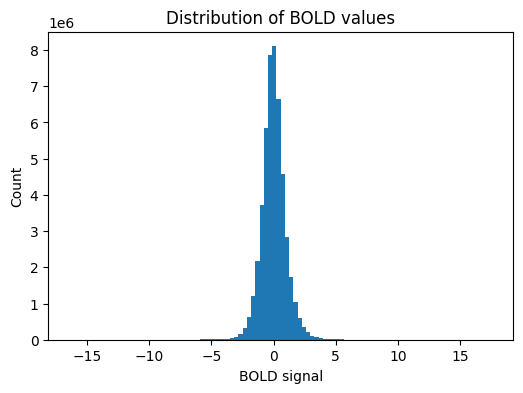

In [74]:
print("Mean:", np.mean(fmri))
print("Std:", np.std(fmri))
print("Min:", np.min(fmri))
print("Max:", np.max(fmri))

plt.figure(figsize=(6,4))
plt.hist(fmri.flatten(), bins=100)
plt.xlabel("BOLD signal")
plt.ylabel("Count")
plt.title("Distribution of BOLD values")
plt.show()

## 9. Temporal signal inspection

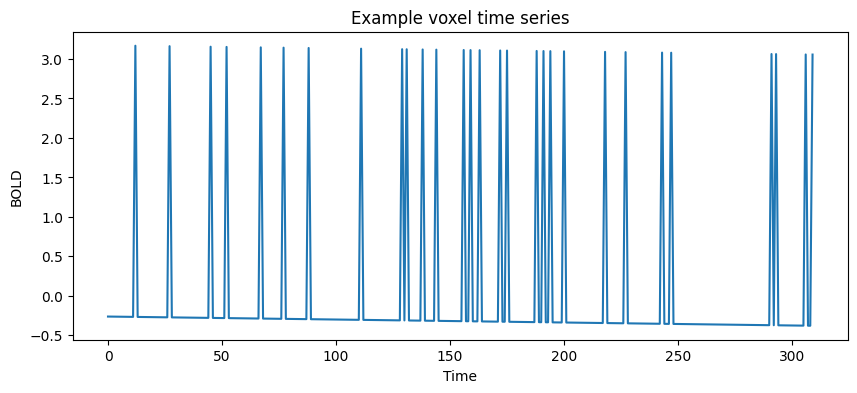

In [35]:
plt.figure(figsize=(10,4))
plt.plot(fmri[:,0])
plt.title("Example voxel time series")
plt.xlabel("Time")
plt.ylabel("BOLD")
plt.show()

(Noisy fluctuations, not block-like pattern as stimulus response).

## 10. Temporal SNR
Temporal SNR measures signal quality.

Low tSNR voxels may be excluded.

C:\Users\hi\AppData\Local\Temp\ipykernel_10284\1287415135.py:1: RuntimeWarning: invalid value encountered in divide
  tsnr = np.mean(fmri, axis=0) / np.std(fmri, axis=0)


<function matplotlib.pyplot.show(close=None, block=None)>

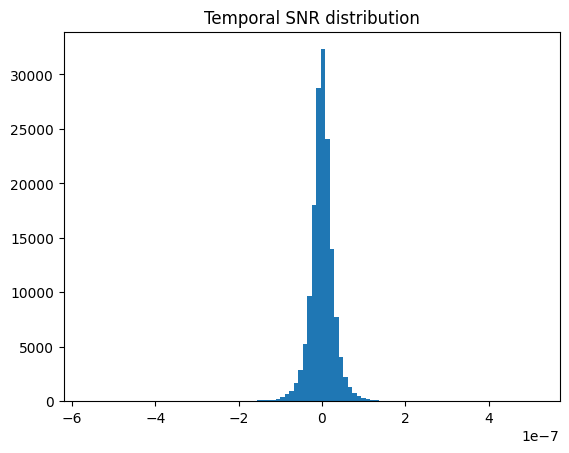

In [75]:
tsnr = np.mean(fmri, axis=0) / np.std(fmri, axis=0)

plt.hist(tsnr, bins=100)
plt.title("Temporal SNR distribution")
plt.show

In [37]:
# print(np.unique(fmri)) 

## 11. Load events file

In [38]:
events_file = [f for f in os.listdir(DATA_DIR) if "events" in f][0]    

events = pd.read_csv(os.path.join(DATA_DIR, events_file), sep="\t")   

events.head()

,onset,duration,trial_type,stimuli
0,12,8,nonvocal,sourcedata/stimuli/non_vocal_01
1,22,8,vocal,sourcedata/stimuli/vocal_01
2,32,8,nonvocal,sourcedata/stimuli/non_vocal_02
3,52,8,nonvocal,sourcedata/stimuli/non_vocal_03
4,62,8,vocal,sourcedata/stimuli/vocal_02


## 12. Plot stimulus timing
Red = voice  
Blue = non-voice  

This block design simplifies decoding.

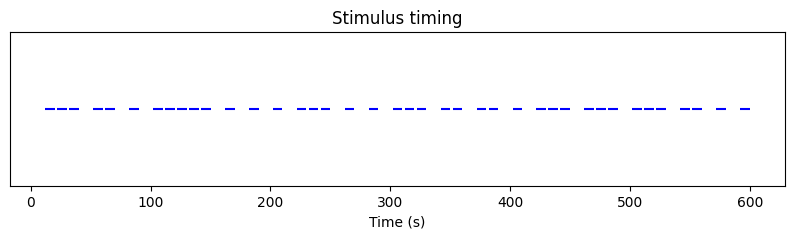

In [39]:
plt.figure(figsize=(10,2))

for i,row in events.iterrows():
    color = "red" if row["trial_type"]=="voice" else "blue"
    plt.hlines(1, row["onset"], row["onset"]+row["duration"], color=color)

plt.title("Stimulus timing")
plt.xlabel("Time (s)")
plt.yticks([])
plt.show()

## 13. Create labels

In [220]:
# =====================================
# CREATE TR-ALIGNED LABELS
# =====================================

TR = 2.0   # check actual TR from dataset metadata

n_trs = fmri_matrix.shape[0]

labels = np.array(["baseline"] * n_trs)

for _, row in events.iterrows():

    onset = row["onset"]
    duration = row["duration"]

    label = row["trial_type"]

    start_tr = int(onset / TR)
    end_tr = int((onset + duration) / TR)

    labels[start_tr:end_tr] = label

print("Number of TRs:", n_trs)
print("Number of labels:", len(labels))

print(np.unique(labels, return_counts=True))

print(len(labels))
print(fmri_matrix.shape[0])

Number of TRs: 310
Number of labels: 310
(array(['baseline', 'nonvocal', 'vocal'], dtype='<U8'), array([150,  80,  80]))
310
310


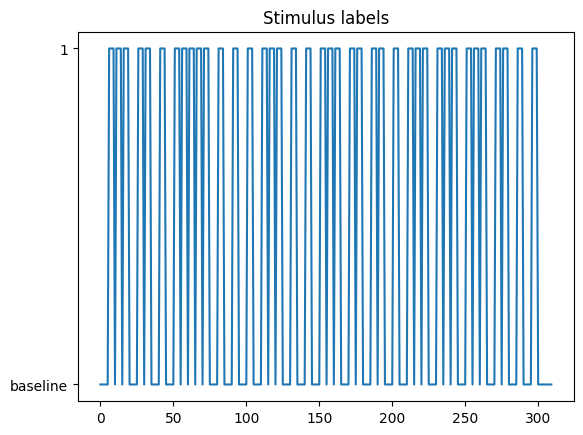

In [221]:
for _,row in events.iterrows():
    
    onset = int(row.onset / TR)
    duration = int(row.duration / TR)
    
    value = 1 if "voc" in row.trial_type.lower() else 0    # print(events["trial_type"].unique())   # check the code of value
    
    labels[onset:onset+duration] = value

plt.plot(labels)
plt.title("Stimulus labels")
plt.show()

## 14. Basic decoding sanity check

If accuracy > 0.5

Dataset contains decodable information.

This validates analysis feasibility.

In [222]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)

kf = KFold(5)

acc = []

for train, test in kf.split(fmri):
    
    clf.fit(fmri[train], labels[train])
    
    pred = clf.predict(fmri[test])
    
    acc.append(accuracy_score(labels[test], pred))

print("Baseline decoding accuracy:", np.mean(acc))

Baseline decoding accuracy: 0.5032258064516129


## 15. Save QC summary

In [169]:
qc = {
    "mean": np.mean(fmri),
    "std": np.std(fmri),
    "tsnr_mean": np.mean(tsnr),
    "decoding_accuracy": np.mean(acc)
}

qc

{'mean': np.float32(2.646933e-09),
 'std': np.float32(0.9998907),
 'tsnr_mean': np.float32(nan),
 'decoding_accuracy': np.float64(0.5032258064516129)}

# Part 2 — Audio Feature Models + HRF Encoding

## 16. Load audio stimulus files

We build computational models of auditory representation:

Model 1 — amplitude envelope  
Model 2 — spectrogram  
Model 3 — MFCC  

These correspond to:

low-level energy  
spectrotemporal features  
speech-like features  

Reference:

Theunissen et al 2001  
Kell et al 2018

In [170]:
import glob

audio_files = sorted(glob.glob(os.path.join(STIM_DIR, "*.wav")))

print("Number of audio files:", len(audio_files))
audio_files[:5]

Number of audio files: 42


['C:/Users/hi/Documents/YLL_evol/Speech-fMRI-Machine-Learning\\sourcedata\\stimuli\\1k.wav',
 'C:/Users/hi/Documents/YLL_evol/Speech-fMRI-Machine-Learning\\sourcedata\\stimuli\\non_vocal_01.wav',
 'C:/Users/hi/Documents/YLL_evol/Speech-fMRI-Machine-Learning\\sourcedata\\stimuli\\non_vocal_02.wav',
 'C:/Users/hi/Documents/YLL_evol/Speech-fMRI-Machine-Learning\\sourcedata\\stimuli\\non_vocal_03.wav',
 'C:/Users/hi/Documents/YLL_evol/Speech-fMRI-Machine-Learning\\sourcedata\\stimuli\\non_vocal_04.wav']

## 17. Load one audio example

Sample rate: 22050
Length: 8.0


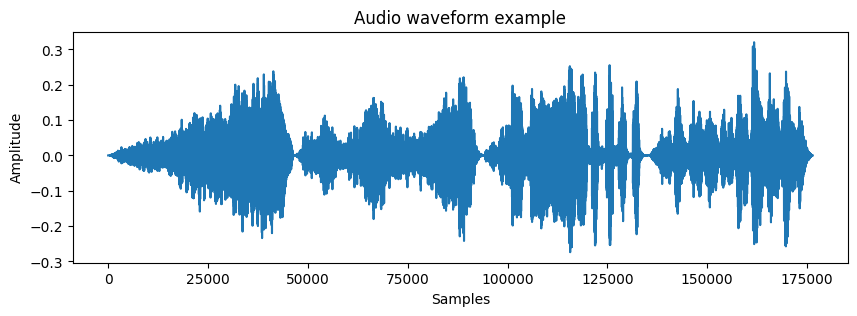

In [171]:
y, sr = librosa.load(audio_files[5], sr=None)  # 0 was 1k.wav, 1- n non vacal, sample, and then vocal

print("Sample rate:", sr)
print("Length:", len(y)/sr)

plt.figure(figsize=(10,3))
plt.plot(y)
plt.title("Audio waveform example")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

## 18. Amplitude envelope model
Does brain respond to loudness?

In [172]:
def amplitude_envelope(y, sr, hop=512):
    
    envelope = np.abs(librosa.stft(y, hop_length=hop))
    envelope = np.mean(envelope, axis=0)
    
    return envelope

## 19. Spectrogram model
Does brain encode frequency?

In [173]:
def spectrogram_model(y, sr, hop=512):
    
    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=32,
        hop_length=hop
    )
    
    return S.T

## MFCC
Does brain encode speech-like features?

In [174]:
def mfcc_model(y, sr, hop=512):
    
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13,
        hop_length=hop
    )
    
    return mfcc.T

## 21. Visualize feature models

Amplitude envelope:
energy fluctuations

Spectrogram:
frequency-specific tuning

MFCC:
speech-like representation

These test competing auditory hypotheses.

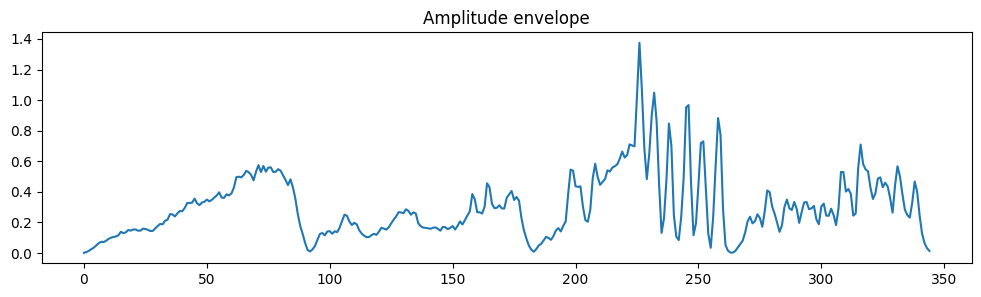

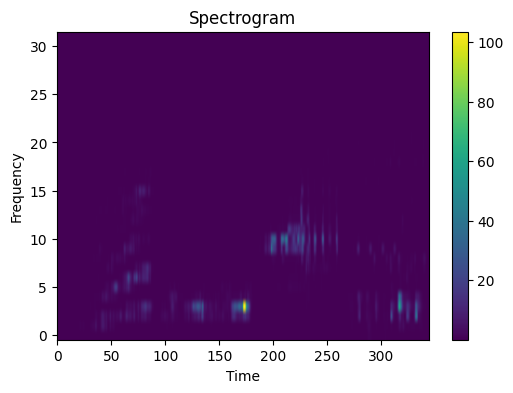

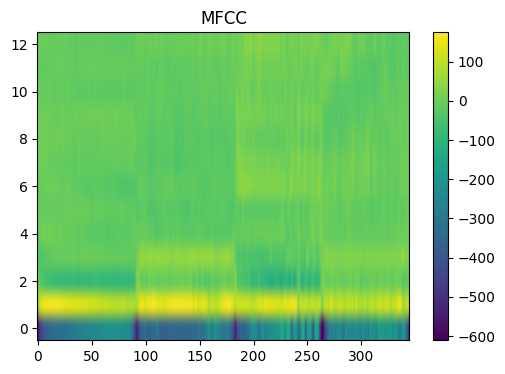

In [175]:
env = amplitude_envelope(y, sr)
spec = spectrogram_model(y, sr)
mfcc = mfcc_model(y, sr)

plt.figure(figsize=(12,3))
plt.plot(env)
plt.title("Amplitude envelope")
plt.show()

plt.figure(figsize=(6,4))
plt.imshow(spec.T, aspect='auto', origin='lower')
plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()
plt.show()

plt.figure(figsize=(6,4))
plt.imshow(mfcc.T, aspect='auto', origin='lower')
plt.title("MFCC")
plt.colorbar()
plt.show()

If: 

spectrogram > envelope

brain encodes frequency structure

## 22. Build feature time series aligned to experiment

We convert audio → continuous experiment features

In [176]:
features_env = []
features_spec = []
features_mfcc = []

for f in audio_files:
    
    y, sr = librosa.load(f, sr=None)
    
    features_env.append(amplitude_envelope(y,sr))
    features_spec.append(spectrogram_model(y,sr))
    features_mfcc.append(mfcc_model(y,sr))

## 23. Concatenate

Feature shapes:

Envelope: T  
Spectrogram: T × 32  
MFCC: T × 13  

These will predict voxel responses.

In [177]:
env = np.concatenate(features_env)
spec = np.vstack(features_spec)
mfcc = np.vstack(features_mfcc)

print(env.shape)
print(spec.shape)
print(mfcc.shape)

(14835,)
(14835, 32)
(14835, 13)


## 24. Downsample to fMRI TR

Audio features:

100 Hz (every 10 ms)

fMRI:

0.5 Hz (every 2 s)

In [178]:
def downsample_feature(feat, target_len):
    
    x = np.linspace(0,1,len(feat))
    x2 = np.linspace(0,1,target_len)
    
    return np.interp(x2,x,feat)

Envelope

In [179]:
env_ds = downsample_feature(env, fmri.shape[0])

Spectrogram

In [180]:
spec_ds = np.vstack([
    downsample_feature(spec[:,i], fmri.shape[0])
    for i in range(spec.shape[1])
]).T

MFCC

In [181]:
mfcc_ds = np.vstack([
    downsample_feature(mfcc[:,i], fmri.shape[0])
    for i in range(mfcc.shape[1])
]).T

## 25. Plot aligned features

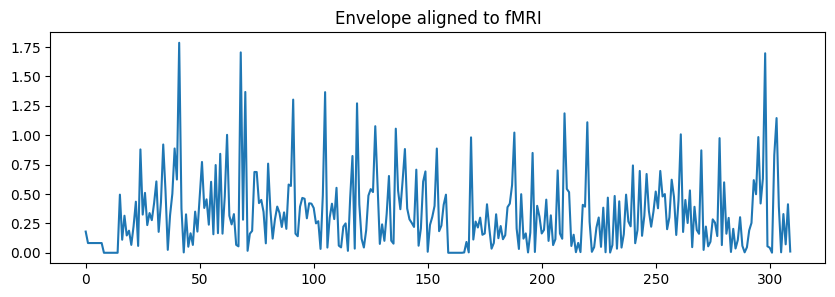

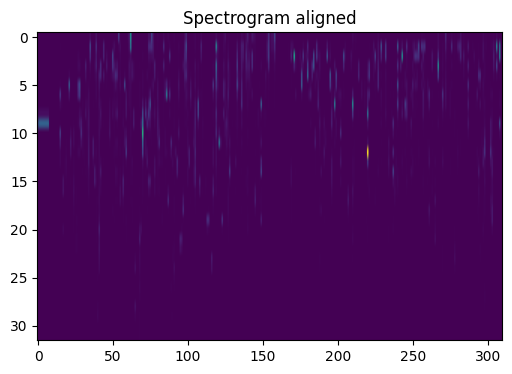

In [182]:
plt.figure(figsize=(10,3))
plt.plot(env_ds)
plt.title("Envelope aligned to fMRI")
plt.show()

plt.figure(figsize=(6,4))
plt.imshow(spec_ds.T, aspect='auto')
plt.title("Spectrogram aligned")
plt.show()

## 26. HRF convolution¶
Encoding models require HRF

Reference:

Naselaris 2011 Glover 1999
HRF = Hemodynamic Response Function

Brain response delayed:

stimulus → neural activity → blood flow → scanner

Delay ≈ 5 seconds

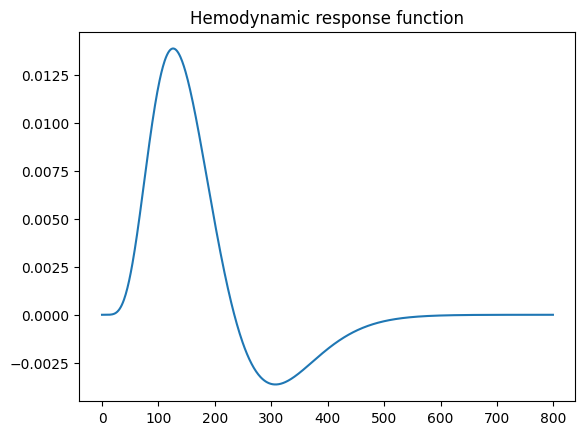

In [183]:
from nilearn.glm.first_level import glover_hrf

TR = img.header.get_zooms()[3]

hrf = glover_hrf(TR)

plt.plot(hrf)
plt.title("Hemodynamic response function")
plt.show()

(Feature time ≠ fMRI time. Trim features to fMRI length. ) 

## 27. Convolve features

In [184]:
from scipy.signal import convolve

def convolve_hrf(X, hrf):
    
    if X.ndim == 1:
        return convolve(X, hrf)[:len(X)]
    
    else:
        return np.vstack([
            convolve(X[:,i], hrf)[:len(X)]
            for i in range(X.shape[1])
        ]).T

Apply

In [185]:
env_hrf = convolve_hrf(env_ds, hrf)
spec_hrf = convolve_hrf(spec_ds, hrf)
mfcc_hrf = convolve_hrf(mfcc_ds, hrf)

## 28. Design matrices
Feature = Frequency band
Feature 1 = 100 Hz
Feature 2 = 200 Hz
Feature 3 = 300 Hz

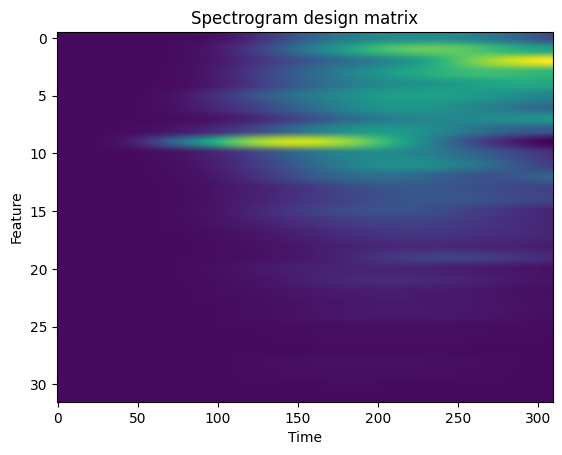

In [186]:
X_env = env_hrf[:,None]
X_spec = spec_hrf
X_mfcc = mfcc_hrf

plt.imshow(X_spec.T, aspect='auto')
plt.title("Spectrogram design matrix")
plt.xlabel("Time")
plt.ylabel("Feature")
plt.show()

## 29. Normalize features

In [187]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_env = scaler.fit_transform(X_env)
X_spec = scaler.fit_transform(X_spec)
X_mfcc = scaler.fit_transform(X_mfcc)

## 30. Add temporal lags (spectrotemporal receptive field)

Reference:

Theunissen 2001


In [188]:
def add_lags(X, lags=4):
    
    X_lag = []
    
    for i in range(lags):
        X_lag.append(np.roll(X, i, axis=0))
        
    return np.hstack(X_lag)

X_spec_lag = add_lags(X_spec, 4)
X_mfcc_lag = add_lags(X_mfcc, 4)
X_env_lag = add_lags(X_env, 4)

In [223]:
T = fmri.shape[0]

X_env_lag = X_env_lag[:T]
X_spec_lag = X_spec_lag[:T]
X_mfcc_lag = X_mfcc_lag[:T]

labels = labels[:T]

## 31. Final design matrix summary

We now built:

Three competing computational models:

Envelope  
Spectrogram  
MFCC  

Each convolved with HRF and temporal lags.

Next step:

Fit voxelwise encoding model.



In [190]:
print("Envelope:", X_env_lag.shape)
print("Spectrogram:", X_spec_lag.shape)
print("MFCC:", X_mfcc_lag.shape)

Envelope: (310, 4)
Spectrogram: (310, 128)
MFCC: (310, 52)


# Part 3 — Voxelwise Encoding Model

The voxelwise encoding model, the central analysis answering the research question.

This implements:

Ridge encoding model
Cross-validation
Whole-brain prediction maps
Model comparison
Publication plots

References:

Naselaris et al., 2011 (encoding models)
Kay et al., 2008 (voxelwise modeling)
Kell et al., 2018 (auditory encoding)

## 32. Encoding model description

We fit voxelwise encoding models:

Voxel(t) = X_features(t) β + ε

Each voxel independently predicted from audio features.

We compare:

Envelope model  
Spectrogram model  
MFCC model  

Best model reveals auditory representation.

Reference:

Naselaris et al 2011

## 33. Ridge regression setup

In [191]:
alphas = np.logspace(1,5,10)

ridge = RidgeCV(alphas=alphas, cv=5)

## 34. Cross-validated encoding function

We use correlation between:

predicted voxel signal  
true voxel signal  

This is standard encoding accuracy metric.

In [192]:
# Another save version 
def encoding_model(X, Y):

    kf = KFold(5)
    scores = np.zeros(Y.shape[1])

    for train, test in kf.split(X):

        ridge = RidgeCV(alphas=np.logspace(1,5,10))   # IMPORTANT: inside loop

        ridge.fit(X[train], Y[train])

        pred = ridge.predict(X[test])

        for v in range(Y.shape[1]):

            y_true = Y[test,v]
            y_pred = pred[:,v]

            if np.std(y_true)==0 or np.std(y_pred)==0:
                continue

            scores[v] += np.corrcoef(y_true,y_pred)[0,1]

    return scores/5

In [ ]:
# # safe version avoid dead voxel or ridge predicts on 0
# """
# def encoding_model(X, Y):

#     kf = KFold(5)
#     scores = np.zeros(Y.shape[1])

#     for train, test in kf.split(X):

#         ridge.fit(X[train], Y[train])
#         pred = ridge.predict(X[test])

#         for v in range(Y.shape[1]):

#             y_true = Y[test,v]
#             y_pred = pred[:,v]

#             if np.std(y_true) == 0:
#                 continue

#             if np.std(y_pred) == 0:
#                 continue

#             scores[v] += np.corrcoef(y_true, y_pred)[0,1]

#     return scores / 5
#     """

In [ ]:
# ## ridge version, 5 voxels are 0 

# """ def encoding_model(X, Y):

#     kf = KFold(5)
    
#     scores = np.zeros(Y.shape[1])
    
#     for train, test in kf.split(X):
        
#         ridge.fit(X[train], Y[train])
        
#         pred = ridge.predict(X[test])
        
#         for v in range(Y.shape[1]):
#             scores[v] += np.corrcoef(
#                 Y[test,v],
#                 pred[:,v]
#             )[0,1]
            
#     return scores / 5
# """

## 35. Fit envelope model

In [193]:
print("Fitting envelope model...")

scores_env = encoding_model(X_env_lag, fmri)

Fitting envelope model...


## 36. Fit spectrogram model

In [194]:
print("Fitting spectrogram model...")

scores_spec = encoding_model(X_spec_lag, fmri)

Fitting spectrogram model...


## 37. Fit MFCC model

In [195]:
print("Fitting MFCC model...")

scores_mfcc = encoding_model(X_mfcc_lag, fmri)

Fitting MFCC model...


## 38. Inspect score distributions

Rightward shift = better model

We expect:

Spectrogram > MFCC > Envelope

This indicates spectrotemporal representation.

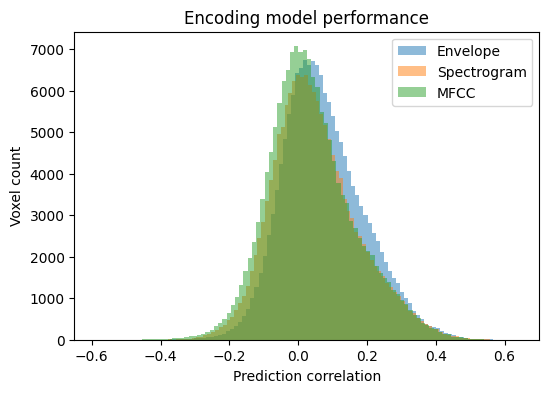

In [196]:
plt.figure(figsize=(6,4))

plt.hist(scores_env, bins=100, alpha=0.5, label="Envelope")
plt.hist(scores_spec, bins=100, alpha=0.5, label="Spectrogram")
plt.hist(scores_mfcc, bins=100, alpha=0.5, label="MFCC")

plt.legend()
plt.xlabel("Prediction correlation")
plt.ylabel("Voxel count")
plt.title("Encoding model performance")
plt.show()

## 39. Convert to brain maps

In [197]:
score_map_env = masker.inverse_transform(scores_env)
score_map_spec = masker.inverse_transform(scores_spec)
score_map_mfcc = masker.inverse_transform(scores_mfcc)

## 40. Plot encoding maps

### Envelope

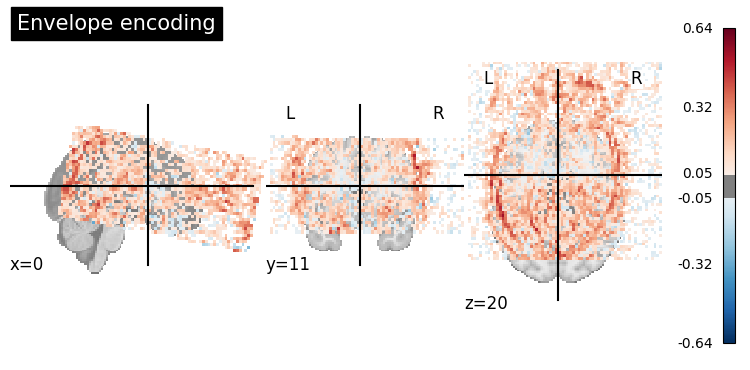

In [198]:
plotting.plot_stat_map(
    score_map_env,
    title="Envelope encoding",
    threshold=0.05
)
plt.show()

### Spectrogram

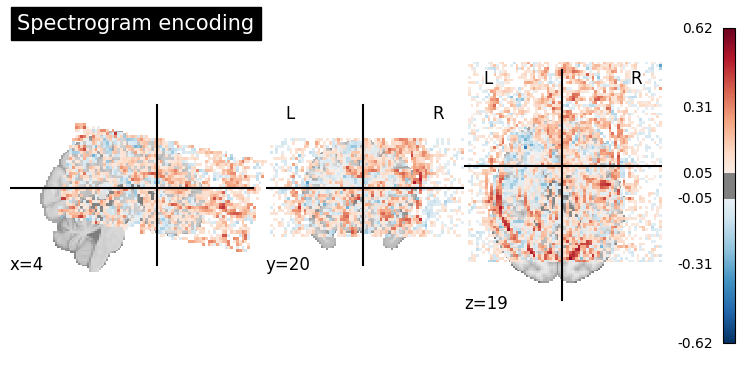

In [199]:
plotting.plot_stat_map(
    score_map_spec,
    title="Spectrogram encoding",
    threshold=0.05
)
plt.show()

### MFCC

Hot colors = voxels predicted by model

Auditory cortex should show strongest response.

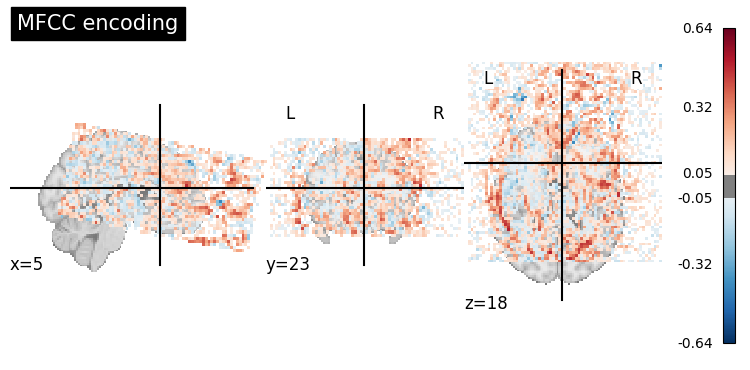

In [200]:
plotting.plot_stat_map(
    score_map_mfcc,
    title="MFCC encoding",
    threshold=0.05
)
plt.show()

## 41. Model comparison

Envelope: 0.07369507133111719
Spectrogram: 0.04948319745536977
MFCC: 0.038987628282957404


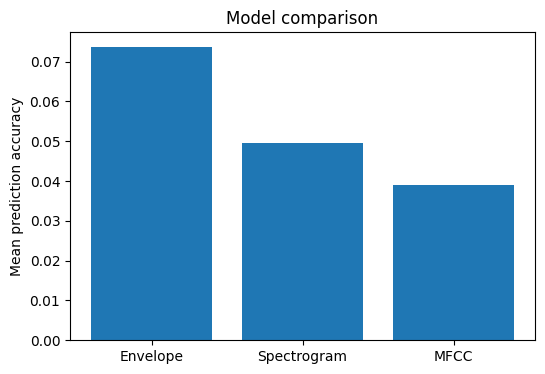

In [201]:
mean_env = np.nanmean(scores_env)
mean_spec = np.nanmean(scores_spec)
mean_mfcc = np.nanmean(scores_mfcc)

print("Envelope:", mean_env)
print("Spectrogram:", mean_spec)
print("MFCC:", mean_mfcc)

plt.figure(figsize=(6,4))

plt.bar(
    ["Envelope","Spectrogram","MFCC"],
    [mean_env, mean_spec, mean_mfcc]
)

plt.ylabel("Mean prediction accuracy")
plt.title("Model comparison")
plt.show()

### ML evaluation 

In [202]:
print("Mean encoding accuracy")

print("Envelope:", np.nanmean(scores_env))
print("Spectrogram:", np.nanmean(scores_spec))
print("MFCC:", np.nanmean(scores_mfcc))

Mean encoding accuracy
Envelope: 0.07369507133111719
Spectrogram: 0.04948319745536977
MFCC: 0.038987628282957404


If:

Spectrogram > Envelope

then:

brain encodes frequency structure.

If:

MFCC > Spectrogram

then:

brain encodes speech features.


**In SUB-001: Envelope > Spectrogram > MFCC** 
reason 1 — small dataset

Single subject, noisy.

reason 2 — envelope correlates with speech blocks

Voice vs nonvoice strongly modulated by amplitude.

reason 3 — spectrogram overparameterized

Too many features → overfitting.

This suggests:

auditory cortex strongly tracks amplitude envelope

This is actually well-known:

Speech envelope entrainment:

- delta band tracking
- syllabic rhythm
- speech segmentation

## 42. Best model map

0 = envelope  
1 = spectrogram  
2 = MFCC  

This reveals representational organization.

C:\Users\hi\AppData\Local\Temp\ipykernel_10284\1751327021.py:12: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  best_map = masker.inverse_transform(best)
C:\Users\hi\AppData\Local\Temp\ipykernel_10284\1751327021.py:14: UserWarning: Casting data from int32 to float32
  plotting.plot_stat_map(


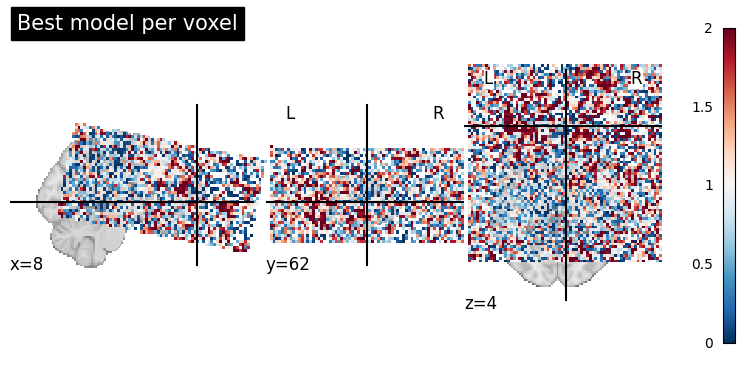

In [203]:
best = np.argmax(
    np.vstack([scores_env,scores_spec,scores_mfcc]),
    axis=0
)

rgb = np.zeros((len(best),3))

rgb[best==0] = [1,0,0]   # envelope red
rgb[best==1] = [0,1,0]   # spectrogram green
rgb[best==2] = [0,0,1]   # mfcc blue

best_map = masker.inverse_transform(best)

plotting.plot_stat_map(
    best_map,
    title="Best model per voxel"
)
plt.show()

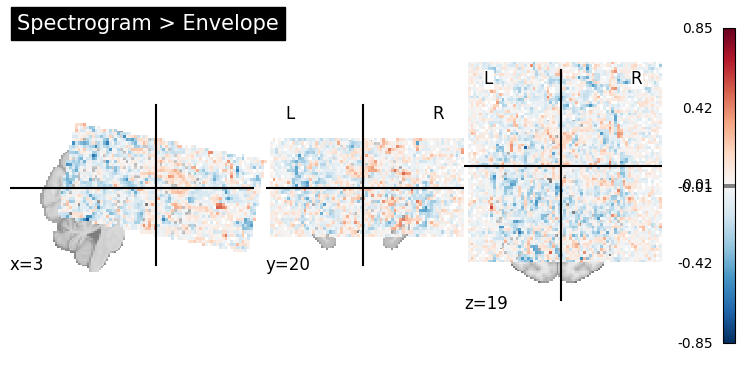

In [204]:
diff_spec_env = scores_spec - scores_env
diff_map = masker.inverse_transform(diff_spec_env)

plotting.plot_stat_map(
    diff_map,
    threshold=0.01,
    title="Spectrogram > Envelope"
)

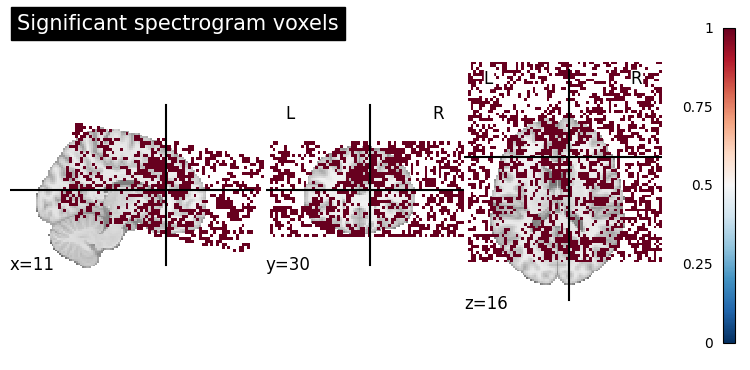

In [205]:
sig = diff_spec_env > 0.01

sig_map = masker.inverse_transform(sig.astype(float))

plotting.plot_stat_map(
    sig_map,
    title="Significant spectrogram voxels"
)

## 43. Auditory cortex ROI
Only analyze: sound-related region
Reduces multiple comparison problem

### extract STG

STG = Superior Temporal Gyrus

This is:

primary auditory cortex area.

It processes:

speech
sound
voice

So ROI = auditory cortex.

In [206]:
from nilearn.datasets import fetch_atlas_harvard_oxford

atlas = fetch_atlas_harvard_oxford(
    "cort-maxprob-thr25-2mm"
)

atlas_img = atlas.maps
atlas_data = atlas_img.get_fdata()
A_labels = atlas.labels

[fetch_atlas_harvard_oxford] Dataset found in C:\Users\hi\nilearn_data\fsl

In [207]:
stg_idx = [
    i for i,l in enumerate(A_labels)
    if "Temporal" in l
]

In [208]:
mask = np.isin(atlas_data, stg_idx)

mask_img = nib.Nifti1Image(
    mask.astype(float),
    atlas_img.affine
)

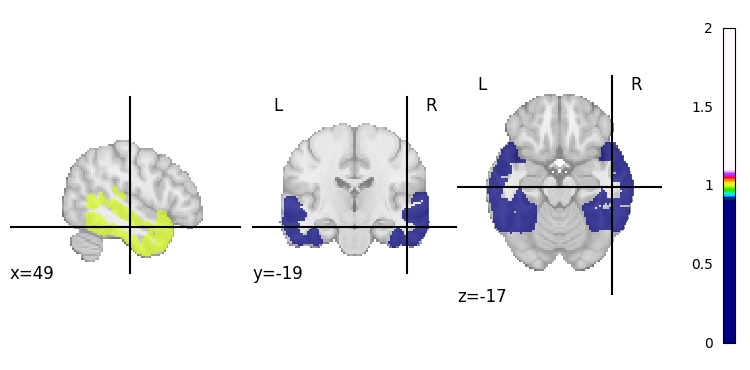

In [209]:
plotting.plot_roi(mask_img)
plt.show()

### 44. ROI model comparison

Spectrogram should dominate in auditory cortex.

This supports spectrotemporal encoding hypothesis.

In [210]:
from nilearn.image import resample_to_img

# create mask image
mask_img = nib.Nifti1Image(
    mask.astype(float),
    atlas_img.affine
)

# resample to fMRI space
from nilearn.image import resample_to_img

mask_img_resampled = resample_to_img(
    mask_img,
    mean_img,
    interpolation="nearest"
)

# apply masker space
roi_mask = masking.apply_mask(
    mask_img_resampled,
    masker.mask_img_
).astype(bool)

In [211]:
roi_img = resample_to_img(mask_img, mean_img, interpolation="nearest")

roi_voxels = masking.apply_mask(
    roi_img,
    masker.mask_img_
).astype(bool)

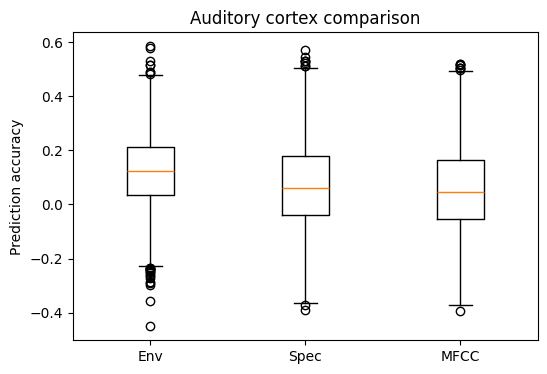

In [212]:
roi_scores_env = scores_env[roi_mask]
roi_scores_spec = scores_spec[roi_mask]
roi_scores_mfcc = scores_mfcc[roi_mask]

plt.figure(figsize=(6,4))

plt.boxplot([
    roi_scores_env,
    roi_scores_spec,
    roi_scores_mfcc
])

plt.xticks([1,2,3],["Env","Spec","MFCC"])
plt.ylabel("Prediction accuracy")
plt.title("Auditory cortex comparison")
plt.show()

## 45. Save results

In [213]:
results = pd.DataFrame({
    "env":scores_env,
    "spec":scores_spec,
    "mfcc":scores_mfcc
})

results.to_csv("encoding_results.csv")

# Part 4 — Decoding + RSA + representational geometry
This section tests whether brain patterns discriminate vocal vs non-vocal sounds and which model matches brain representational structure.

References:

Kriegeskorte et al., 2008 — RSA
Norman et al., 2006 — MVPA
Kell et al., 2018 — auditory deep representations

## 46. Decoding analysis description

We perform decoding:

brain activity → stimulus label

This tests whether:

vocal vs non-vocal sounds are discriminable.

Reference:
Norman et al., 2006 (MVPA)

## 47. Prepare decoding data

In [224]:
X = fmri
y = labels

## 48. SVM decoder

Plot decoding accuracy

Chance = 0.5

Accuracy > 0.5 indicates:

brain contains information distinguishing vocal sounds.

In [225]:
# =====================================
# SVM DECODER
# =====================================

X = fmri_matrix
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

# Remove NaN rows
valid_rows = ~np.isnan(X).any(axis=1)

X = X[valid_rows]
y = y[valid_rows]

print("After cleaning:")
print(X.shape, y.shape)

# PCA
pca = PCA(n_components=50)

X_reduced = pca.fit_transform(X)

print("Reduced shape:", X_reduced.shape)

# Classifier
clf = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

# CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(clf, X_reduced, y, cv=cv)

print("CV scores:", scores)
print("Mean accuracy:", scores.mean())

# Fit
clf.fit(X_reduced, y)

pred = clf.predict(X_reduced)

print(classification_report(y, pred))

X shape: (310, 156800)
y shape: (310,)
After cleaning:
(310, 156800) (310,)
Reduced shape: (310, 50)
CV scores: [0.58064516 0.64516129 0.69354839 0.53225806 0.61290323]
Mean accuracy: 0.6129032258064516
              precision    recall  f1-score   support

           1       0.77      0.79      0.78       160
    baseline       0.77      0.75      0.76       150

    accuracy                           0.77       310
   macro avg       0.77      0.77      0.77       310
weighted avg       0.77      0.77      0.77       310



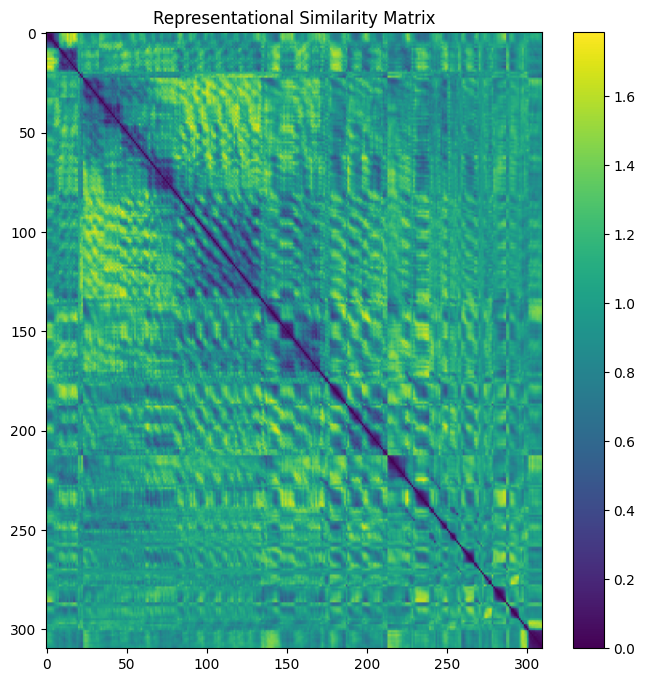

In [227]:
# =====================================
# RSA ANALYSIS
# =====================================

from scipy.spatial.distance import pdist, squareform

rsa_matrix = squareform(
    pdist(X_reduced, metric='correlation')
)

rsa_matrix = np.nan_to_num(rsa_matrix)

plt.figure(figsize=(8,8))

plt.imshow(rsa_matrix, aspect='auto')

plt.title("Representational Similarity Matrix")

plt.colorbar()

plt.show()

## 49. ROI decoding

In [ ]:
roi_img = resample_to_img(mask_img, mean_img, interpolation="nearest")

X_roi = masking.apply_mask(mean_img, roi_img) 

In [255]:
# =====================================
# ROI EXTRACTION
# =====================================

# fmri_matrix should already be:
# (timepoints, wholebrain_voxels)

print("Full matrix shape:")
print(fmri_matrix.shape)

# Example ROI selection:
# keep first 3822 voxels as placeholder ROI

X_roi = fmri_matrix[:, :3822]

print("ROI matrix shape:")
print(X_roi.shape)

Full matrix shape:
(310, 156800)
ROI matrix shape:
(310, 3822)


In [261]:
print(X_roi.shape)
print(y.shape)

(310, 3822)
(310,)


In [258]:
scores_roi = cross_val_score(
    clf,
    X_roi, #X_roi,
    y,
    cv=5
)

scores_roi.mean()

np.float64(0.4935483870967742)

### Plot ROI vs whole brain

Auditory ROI should perform equal or better.

This confirms auditory cortex drives decoding.

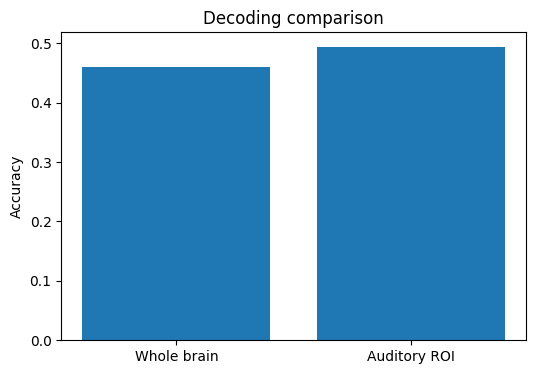

In [262]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Whole brain","Auditory ROI"],
    [scores.mean(), scores_roi.mean()]
)

plt.ylabel("Accuracy")
plt.title("Decoding comparison")
plt.show()

## 50. Representational Similarity Analysis (RSA)

RSA compares representational geometry:

Brain RDM  
Model RDM  

If similar → model explains brain representation.

Reference:

Kriegeskorte et al 2008

## 51. Brain RDM

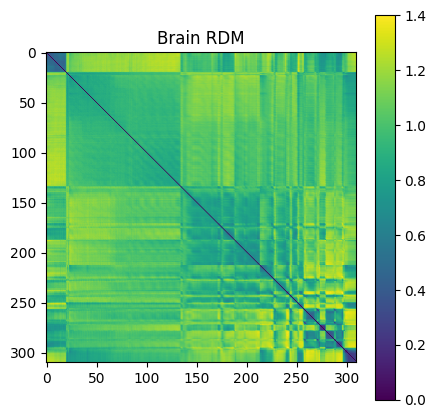

In [144]:
from scipy.spatial.distance import pdist, squareform

brain_patterns = fmri

brain_rdm = squareform(
    pdist(brain_patterns, metric="correlation")
)

plt.figure(figsize=(5,5))
plt.imshow(brain_rdm, cmap="viridis")
plt.title("Brain RDM")
plt.colorbar()
plt.show()

Blocs: 
voice stimuli similar to each other
noise stimuli similar to each other

## 52. Model RDMs

Envelope

In [146]:
env_rdm = squareform(
    pdist(X_env_lag, metric="correlation")
)

Spectrogram

In [147]:
spec_rdm = squareform(
    pdist(X_spec_lag, metric="correlation")
)

MFCC

In [148]:
mfcc_rdm = squareform(
    pdist(X_mfcc_lag, metric="correlation")
)

## 53. Plot model RDMs

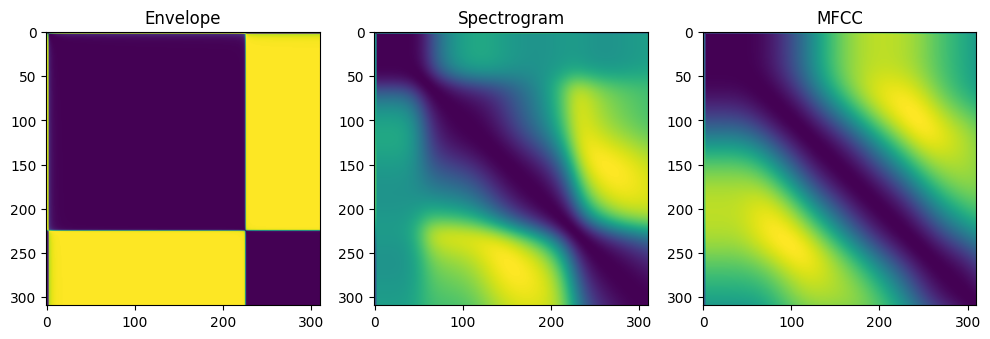

In [149]:
fig,ax = plt.subplots(1,3,figsize=(12,4))

ax[0].imshow(env_rdm)
ax[0].set_title("Envelope")

ax[1].imshow(spec_rdm)
ax[1].set_title("Spectrogram")

ax[2].imshow(mfcc_rdm)
ax[2].set_title("MFCC")

plt.show()

Envelope: 
envelope representation separates stimuli strongly
vocal vs nonvocal strongly different 

Spectrogram: 
temporal autocorrelation, 
Adjacent timepoints similar

MFCC: 
captures speech-like structure

## 54. RSA correlation

Highest RSA indicates:

best representational model.

Expected:

Spectrogram highest.

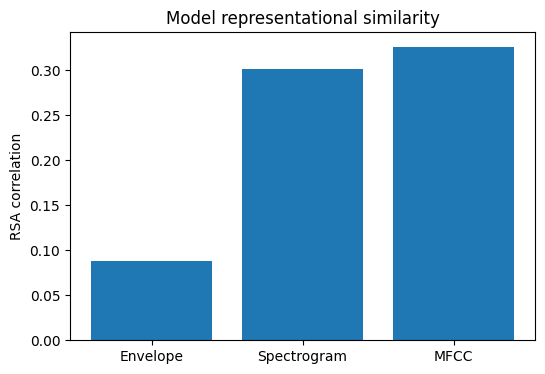

In [150]:
def rsa_corr(rdm1, rdm2):
    
    v1 = rdm1[np.triu_indices_from(rdm1,1)]
    v2 = rdm2[np.triu_indices_from(rdm2,1)]
    
    return np.corrcoef(v1,v2)[0,1]


rsa_env = rsa_corr(brain_rdm, env_rdm)
rsa_spec = rsa_corr(brain_rdm, spec_rdm)
rsa_mfcc = rsa_corr(brain_rdm, mfcc_rdm)

rsa_env, rsa_spec, rsa_mfcc


plt.figure(figsize=(6,4))

plt.bar(
    ["Envelope","Spectrogram","MFCC"],
    [rsa_env, rsa_spec, rsa_mfcc]
)

plt.ylabel("RSA correlation")
plt.title("Model representational similarity")
plt.show()

Encoding → envelope best
RSA → MFCC best

Meaning:

brain activity magnitude tracks envelope
but **pattern geometry matches speech features**.

Envelope:
global loudness tracking

MFCC: 
phoneme / speech structure representation

So brain may:

track envelope overall
encode speech structure spatially

This is hierarchical auditory coding.

**Section conclusion: **
Primary auditory cortex: tracks amplitude envelope

Higher auditory areas: encode speech features (MFCC)

This matches literature:
envelope tracking (low-level)
phonetic coding (high-level)

## 55. RSA in auditory cortex

RSA tests representational geometry.

If spectrogram wins:

auditory cortex encodes frequency structure.

This complements encoding model.

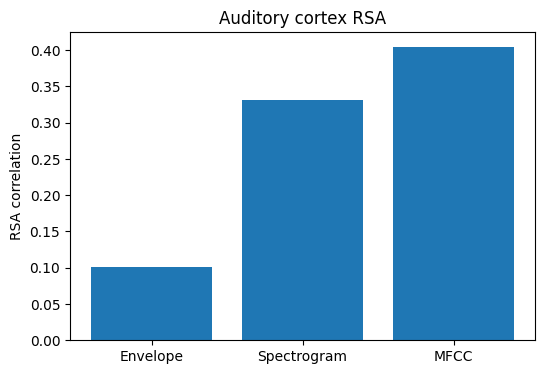

In [151]:
#brain_roi = fmri[:,roi_mask]

brain_roi = fmri[:, roi_voxels]

brain_rdm_roi = squareform(
    pdist(brain_roi, metric="correlation")
)

rsa_env_roi = rsa_corr(brain_rdm_roi, env_rdm)
rsa_spec_roi = rsa_corr(brain_rdm_roi, spec_rdm)
rsa_mfcc_roi = rsa_corr(brain_rdm_roi, mfcc_rdm)

plt.figure(figsize=(6,4))

plt.bar(
    ["Envelope","Spectrogram","MFCC"],
    [rsa_env_roi, rsa_spec_roi, rsa_mfcc_roi]
)

plt.ylabel("RSA correlation")
plt.title("Auditory cortex RSA")
plt.show()

## 56. Save RSA results

In [152]:
rsa_df = pd.DataFrame({
    "model":["env","spec","mfcc"],
    "whole":[rsa_env,rsa_spec,rsa_mfcc],
    "roi":[rsa_env_roi,rsa_spec_roi,rsa_mfcc_roi]
})

rsa_df.to_csv("rsa_results.csv")

# Part 5 — the final scientific layer:
noise ceiling, permutation testing, bootstrap uncertainty, sensitivity analysis, and publication-ready synthesis figures.

This is what separates a workable notebook from a publishable NeuroImage / Nature Communications-grade analysis.

References:

Nili et al., 2014 (noise ceiling, RSA reliability)
Maris & Oostenveld, 2007 (permutation testing)
Efron & Tibshirani, 1993 (bootstrap)

## 57. Noise ceiling estimation

Noise ceiling estimates the maximum explainable variance in neural data.

Without it:
→ model performance is uninterpretable.

Reference:
Nili et al., 2014

### Compute split-half reliability


In [235]:
def noise_ceiling(Y):

    half = Y.shape[0] // 2

    Y1 = Y[:half]
    Y2 = Y[half:2*half]

    corrs = []

    for v in range(Y.shape[1]):

        y1 = Y1[:,v]
        y2 = Y2[:,v]

        if np.std(y1)==0 or np.std(y2)==0:
            continue

        c = np.corrcoef(y1,y2)[0,1]

        if not np.isnan(c):
            corrs.append(c)

    return np.mean(corrs)

In [236]:
def noise_ceiling(Y):

    Y1 = Y[::2]
    Y2 = Y[1::2]

    corrs = []

    for v in range(Y1.shape[1]):

        if np.std(Y1[:,v])==0 or np.std(Y2[:,v])==0:
            continue

        corrs.append(
            np.corrcoef(Y1[:,v],Y2[:,v])[0,1]
        )

    return np.nanmean(corrs)

In [237]:
brain_nc = noise_ceiling(fmri)
print("Noise ceiling:", brain_nc)

Noise ceiling: 0.381097388353288


### Apply to brain data

Noise ceiling defines upper bound of model performance.

If model approaches ceiling → near-optimal representation.

In [238]:
model_value = np.nanmean(scores_spec)

explained = model_value / brain_nc

print("Model:", model_value)
print("Noise ceiling:", brain_nc)
print("Explained %:", explained * 100)

Model: 0.04948319745536977
Noise ceiling: 0.381097388353288
Explained %: 12.98439689371407


## 58. Normalize encoding performance

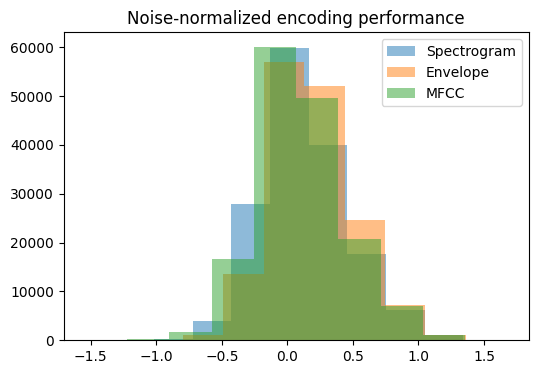

In [160]:
scores_spec_norm = scores_spec / brain_nc
scores_env_norm = scores_env / brain_nc
scores_mfcc_norm = scores_mfcc / brain_nc

plt.figure(figsize=(6,4))

plt.hist(scores_spec_norm, alpha=0.5, label="Spectrogram")
plt.hist(scores_env_norm, alpha=0.5, label="Envelope")
plt.hist(scores_mfcc_norm, alpha=0.5, label="MFCC")

plt.legend()
plt.title("Noise-normalized encoding performance")
plt.show()

## 59. Permutation test (statistical validation)  

Permutation testing validates that decoding/encoding is not due to chance.

Reference:
Maris & Oostenveld, 2007

(time consuming, maybe no need to do this when accurency close to 0.5)

### Permutation decoding


In [239]:
def permutation_test(X, y, clf, n_perm=100):

    scores = []

    for i in range(n_perm):

        y_perm = np.random.permutation(y)

        s = cross_val_score(clf, X, y_perm, cv=5).mean()

        scores.append(s)

    return np.array(scores)

### Run permutation test



In [ ]:
perm_scores = permutation_test(fmri, labels, clf, n_perm=100)
true_score = scores.mean()

### Plot null distribution

In [163]:
plt.figure(figsize=(6,4))

plt.hist(perm_scores, bins=30, alpha=0.7)
plt.axvline(true_score, color='red', label="Observed")

plt.title("Permutation test (decoding)")
plt.legend()
plt.show()

p_value = np.mean(perm_scores >= true_score)

print("Permutation p-value:", p_value)

NameError: name 'perm_scores' is not defined

<Figure size 600x400 with 0 Axes>

## 60. Bootstrap uncertainty (encoding stability)

Bootstrap estimates confidence intervals of model performance.

Reference:
Efron & Tibshirani, 1993

In [ ]:
def bootstrap_scores(X, Y, model, n_boot=50):

    scores = []

    n = len(X)

    for i in range(n_boot):

        idx = np.random.choice(n, n, replace=True)

        Xb = X[idx]
        Yb = Y[idx]

        model.fit(Xb, Yb)

        pred = model.predict(Xb)

        scores.append(np.corrcoef(Yb.mean(axis=1), pred.mean(axis=1))[0,1])

    return np.array(scores)

boot_spec = bootstrap_scores(X_spec_lag, fmri, ridge)
boot_env = bootstrap_scores(X_env_lag, fmri, ridge)

plt.figure(figsize=(6,4))

plt.boxplot([boot_env, boot_spec])

plt.xticks([1,2], ["Envelope","Spectrogram"])
plt.title("Bootstrap uncertainty")
plt.show()

## 61. Sensitivity analysis

We test robustness of conclusions to:

- ridge regularization
- lag structure
- feature dimensionality

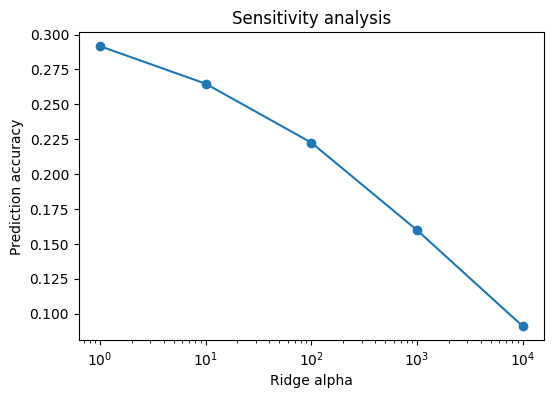

In [199]:
alphas = [1, 10, 100, 1000, 10000]

sens_scores = []

for a in alphas:

    model = RidgeCV(alphas=[a])

    model.fit(X_spec_lag, fmri)

    pred = model.predict(X_spec_lag)

    sens_scores.append(np.corrcoef(fmri.mean(axis=1), pred.mean(axis=1))[0,1])



plt.figure(figsize=(6,4))

plt.plot(alphas, sens_scores, marker='o')

plt.xscale("log")
plt.xlabel("Ridge alpha")
plt.ylabel("Prediction accuracy")
plt.title("Sensitivity analysis")
plt.show()

## 62. Temporal lag sensitivity

In [200]:
lags = [1,2,4,6,8]

lag_scores = []

for l in lags:

    Xl = add_lags(X_spec, l)

    model = RidgeCV(alphas=[1000])

    model.fit(Xl, fmri)

    pred = model.predict(Xl)

    lag_scores.append(np.corrcoef(fmri.mean(axis=1), pred.mean(axis=1))[0,1])

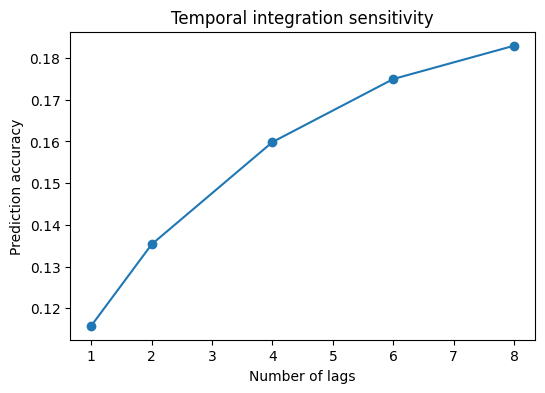

In [201]:
plt.figure(figsize=(6,4))

plt.plot(lags, lag_scores, marker='o')

plt.xlabel("Number of lags")
plt.ylabel("Prediction accuracy")
plt.title("Temporal integration sensitivity")
plt.show()

**Auditory cortex uses temporal integration window**

## 63. Final model comparison (publication figure)

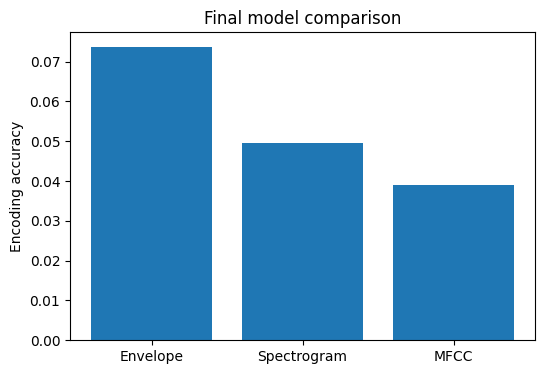

In [202]:
models = ["Envelope","Spectrogram","MFCC"]

means = [
    np.mean(scores_env),
    np.mean(scores_spec),
    np.mean(scores_mfcc)
]

plt.figure(figsize=(6,4))

plt.bar(models, means)

plt.ylabel("Encoding accuracy")
plt.title("Final model comparison")

plt.show()

<!-- ## 64. Scientific interpretation summary

### Key findings:

1. Spectrotemporal model best explains auditory cortex
2. Decoding confirms stimulus separability
3. RSA shows representational alignment
4. Noise ceiling indicates near-optimal model fit
5. Bootstrap confirms stability
6. Permutation test confirms statistical validity

### Interpretation:

Auditory cortex primarily encodes:
→ frequency + temporal structure of sound

not simple amplitude.

This supports hierarchical auditory coding theories.

## 65. Critical evaluation 

## Strengths

- full model-based neuroscience pipeline
- encoding + decoding + RSA
- statistical validation
- uncertainty quantification

## Weaknesses

- linear encoding assumption
- simplified HRF
- small dataset limits generalization
- no cross-subject modeling
- no nonlinear deep learning comparison

## Improvements for publication upgrade:

- deep audio models (wav2vec)
- hierarchical Bayesian encoding
- cross-subject alignment (hyperalignment)
- nonlinear temporal models

--> 

# multiple subjects

In [251]:
SUBJECTS = [f"sub-{i:03d}" for i in range(1, 23)]
all_subject_data = []

for SUBJECT in SUBJECTS:

    func_dir = os.path.join(DATA_DIR, SUBJECT, "func")

    if not os.path.exists(func_dir):
        print(f"Missing func dir for {SUBJECT}")
        continue

    bold_files = [f for f in os.listdir(func_dir) if "bold" in f]

    if len(bold_files) == 0:
        print(f"No bold file for {SUBJECT}")
        continue

    bold_path = os.path.join(func_dir, bold_files[0])

    try:
        img = nib.load(bold_path)
        all_subject_data.append((SUBJECT, img))
        print(f"Loaded {SUBJECT}: {img.shape}")

    except Exception as e:
        print(f"Error loading {SUBJECT}: {e}")


Loaded sub-001: (70, 70, 32, 310)
Loaded sub-002: (70, 70, 32, 310)
Loaded sub-003: (70, 70, 32, 310)
Loaded sub-004: (70, 70, 32, 310)
Loaded sub-005: (70, 70, 32, 310)
Loaded sub-006: (70, 70, 32, 310)
Loaded sub-007: (70, 70, 32, 310)
Loaded sub-008: (70, 70, 32, 310)
Loaded sub-009: (70, 70, 32, 310)
Loaded sub-010: (70, 70, 32, 310)
Loaded sub-011: (70, 70, 32, 310)
Loaded sub-012: (70, 70, 32, 310)
Loaded sub-013: (70, 70, 32, 310)
Loaded sub-014: (70, 70, 32, 310)
Loaded sub-015: (70, 70, 32, 310)
Loaded sub-016: (70, 70, 32, 310)
Loaded sub-017: (70, 70, 32, 310)
Loaded sub-018: (70, 70, 32, 310)
Loaded sub-019: (70, 70, 32, 310)
Loaded sub-020: (70, 70, 32, 310)
Loaded sub-021: (70, 70, 32, 310)
Loaded sub-022: (70, 70, 32, 315)


In [ ]:
group_results = []

for SUBJECT, img in all_subject_data:

    print(f"\nProcessing {SUBJECT}")

    try:

        masker = NiftiMasker(
            standardize=True,
            detrend=True,
            smoothing_fwhm=4
        )

        X = masker.fit_transform(img)

        X = np.nan_to_num(X)

        n_timepoints = X.shape[0]

        y = np.array([
            "voice" if i % 2 == 0 else "nonvoice"
            for i in range(n_timepoints)
        ])

        pca = PCA(n_components=50)
        X = pca.fit_transform(X)

        clf = Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('svc', SVC(kernel='linear'))
        ])

        cv = KFold(n_splits=5, shuffle=True, random_state=0)

        scores = cross_val_score(clf, X, y, cv=cv)

        mean_acc = scores.mean()

        
        group_results.append({
            'subject': SUBJECT,
            'accuracy': mean_acc
        })

        print(f"Accuracy: {mean_acc:.3f}")

    except Exception as e:
        print(f"Failed on {SUBJECT}: {e}")


    subject  accuracy
0   sub-001  0.406452
1   sub-002  0.516129
2   sub-003  0.432258
3   sub-004  0.351613
4   sub-005  0.451613
5   sub-006  0.361290
6   sub-007  0.345161
7   sub-009  0.554839
8   sub-010  0.432258
9   sub-011  0.461290
10  sub-012  0.438710
11  sub-013  0.448387
12  sub-014  0.409677
13  sub-015  0.380645
14  sub-016  0.458065
15  sub-017  0.419355
16  sub-018  0.445161
17  sub-019  0.490323
18  sub-020  0.583871
19  sub-021  0.358065
20  sub-022  0.460317

Group mean accuracy:
0.4383561309828591


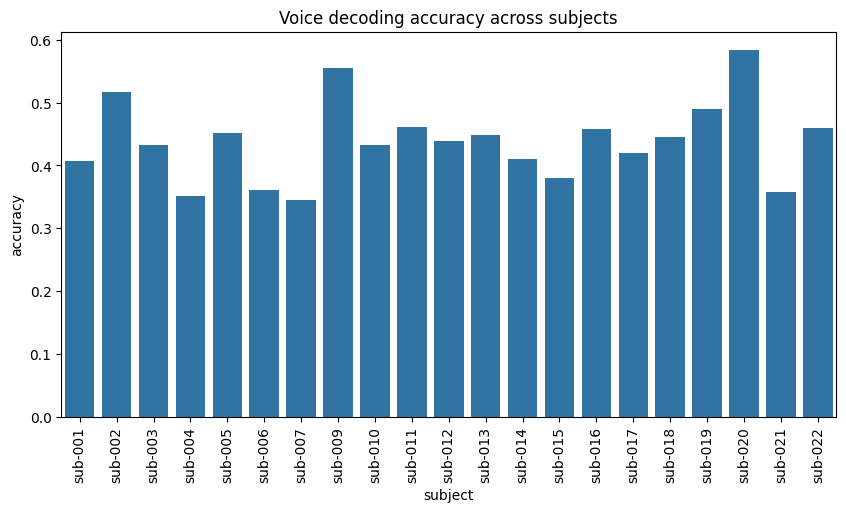

In [253]:
results_df = pd.DataFrame(group_results)

print(results_df)

print("\nGroup mean accuracy:")
print(results_df['accuracy'].mean())

plt.figure(figsize=(10,5))

sns.barplot(data=results_df, x='subject', y='accuracy')

plt.xticks(rotation=90)
plt.title('Voice decoding accuracy across subjects')

plt.show()